In [1]:
import sys

print(sys.executable)

c:\Users\magda\OneDrive\Desktop\automated_report\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
import pandas as pd


path = Path("data/web_traffic_marketing_data_2026.csv")

df = pd.read_csv(path)

print(df.dtypes)


date                        str
channel                     str
device                      str
sessions                  int64
users                     int64
pageviews                 int64
bounce_rate             float64
avg_session_duration    float64
conversions             float64
revenue                 float64
marketing_cost          float64
dtype: object


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  6575 non-null   str    
 1   channel               6575 non-null   str    
 2   device                6575 non-null   str    
 3   sessions              6575 non-null   int64  
 4   users                 6575 non-null   int64  
 5   pageviews             6575 non-null   int64  
 6   bounce_rate           6569 non-null   float64
 7   avg_session_duration  6571 non-null   float64
 8   conversions           6572 non-null   float64
 9   revenue               6572 non-null   float64
 10  marketing_cost        6575 non-null   float64
dtypes: float64(5), int64(3), str(3)
memory usage: 565.2 KB


In [4]:
print(df.describe())

          sessions        users    pageviews  bounce_rate  \
count  6575.000000  6575.000000  6575.000000  6569.000000   
mean    288.214753   243.254144   805.200304     0.414457   
std     175.060455   148.547435   506.718733     0.081970   
min      20.000000    15.000000    42.000000    -0.050000   
25%     148.000000   124.000000   405.000000     0.357000   
50%     259.000000   217.000000   714.000000     0.407000   
75%     405.000000   342.000000  1120.500000     0.467000   
max     852.000000   767.000000  2835.000000     1.150000   

       avg_session_duration  conversions       revenue  marketing_cost  
count           6571.000000  6572.000000   6572.000000     6575.000000  
mean             152.844468     9.163268   7809.154501      757.711673  
std               34.866759     6.501417   5982.668616     1248.608724  
min               37.000000     0.000000      0.000000        0.000000  
25%              127.000000     4.000000   2949.537500        0.000000  
50%         

In [5]:
print(df.isna().sum())

date                    0
channel                 0
device                  0
sessions                0
users                   0
pageviews               0
bounce_rate             6
avg_session_duration    4
conversions             3
revenue                 3
marketing_cost          0
dtype: int64


In [6]:
from src.report_tools.analysis import (
    calculate_channel_kpis, 
    calculate_device_kpis,
    calculate_daily_kpis
)

channel_kpis = calculate_channel_kpis(df)

channel_kpis

,channel,sessions,users,pageviews,conversions,revenue,marketing_cost,avg_bounce_rate,avg_session_duration,conversion_rate,revenue_per_session,roas
0,Direct,273016,230845,764584,11191.0,10972005.98,0.00,0.364106,153,4.099027,40.188143,<NA>
1,Email,232906,196478,651917,12214.0,11296116.84,279305.57,0.325083,152,5.244176,48.500755,40.443579
2,Organic Search,515164,435193,1434276,16145.0,13708100.09,0.00,0.394520,152,3.133953,26.609196,<NA>
3,Paid Search,397563,335097,1115981,10971.0,8650334.23,3384154.55,0.454694,154,2.759563,21.758399,2.556129
4,Referral,150152,126415,418665,3896.0,2942005.15,270764.18,0.411743,153,2.594704,19.593513,10.865563
5,Social Media,326211,275368,908769,5804.0,3753201.09,1047729.95,0.536813,153,1.779217,11.505440,3.582222


In [7]:
device_kpis = calculate_device_kpis(df)

device_kpis

,device,sessions,users,pageviews,conversions,revenue,avg_bounce_rate,avg_session_duration,conversion_rate,revenue_per_session
0,Desktop,750433,633463,2097628,25753.0,21900550.59,0.400995,184,3.431752,29.183885
1,Mobile,867972,732975,2421517,25611.0,21833256.52,0.440331,125,2.950671,25.154333
2,Tablet,276607,232958,775047,8857.0,7587956.27,0.402038,150,3.202016,27.432264


In [8]:
daily_kpis = calculate_daily_kpis(df)

daily_kpis.head()

,date,sessions,users,pageviews,conversions,revenue,marketing_cost,conversion_rate,revenue_per_session,roas
0,2026-01-01,4879,4062,13170,169.0,145634.04,13521.67,3.463825,29.849158,10.770418
1,2026-01-02,4745,3940,12419,146.0,126237.86,12759.15,3.076923,26.604396,9.893908
2,2026-01-03,3874,3317,12245,129.0,111729.41,11105.34,3.329892,28.840839,10.060873
3,2026-01-04,3999,3400,11215,134.0,112274.59,9571.03,3.350838,28.075666,11.730670
4,2026-01-05,4912,4196,14351,154.0,129031.11,11482.94,3.135179,26.268548,11.236766


C:\Users\magda\AppData\Local\Temp\ipykernel_13076\3695123470.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


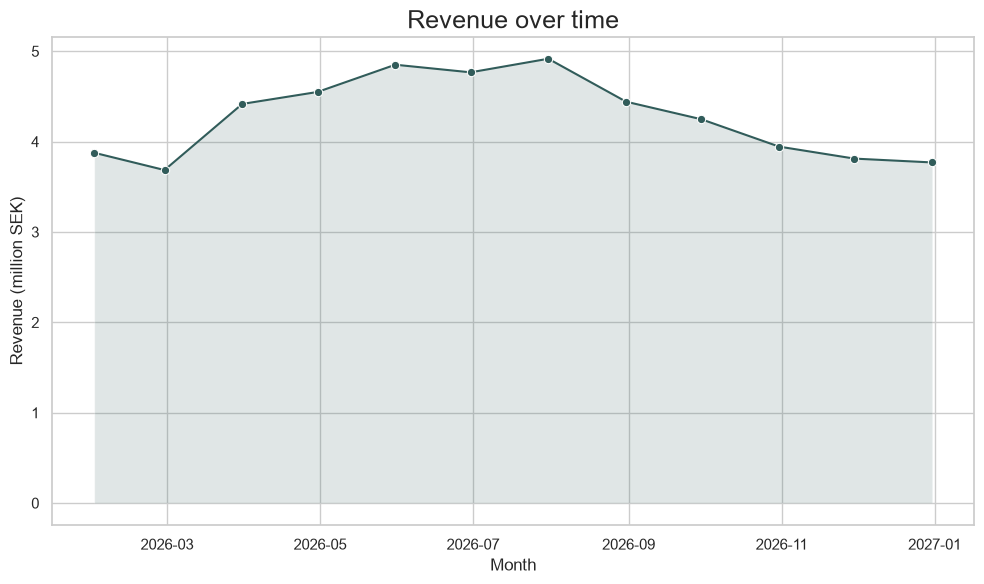

In [9]:
from src.report_tools.visualization import plot_revenue_over_time
from src.report_tools.cleaning import clean_web_analytics

cleaned_df = clean_web_analytics(df)

fig = plot_revenue_over_time(cleaned_df)
fig.show()

C:\Users\magda\AppData\Local\Temp\ipykernel_13076\2418824173.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


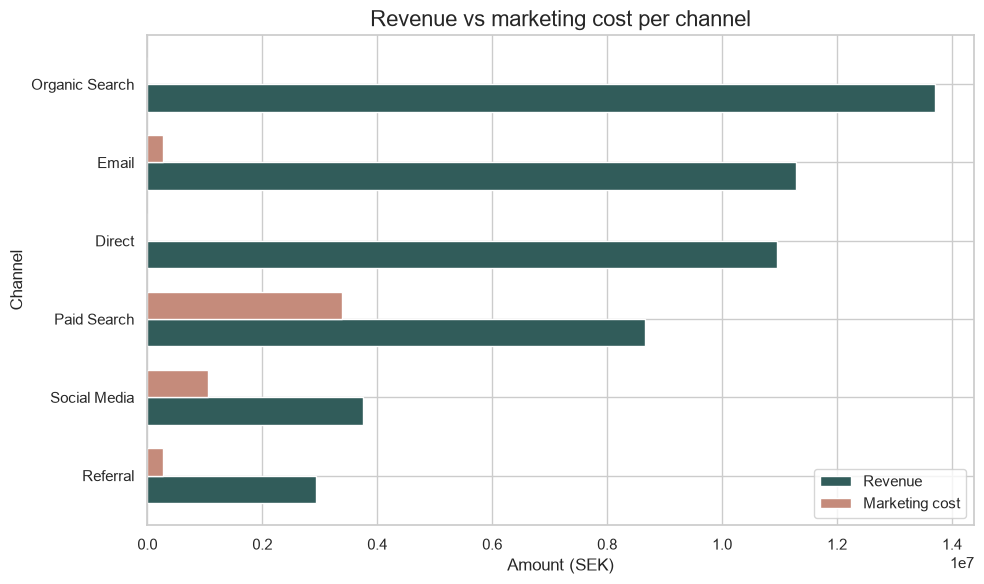

In [10]:
from src.report_tools.visualization import plot_revenue_vs_cost_by_channel

channel_kpis = calculate_channel_kpis(cleaned_df)

fig = plot_revenue_vs_cost_by_channel(channel_kpis)

fig.show()

C:\Users\magda\AppData\Local\Temp\ipykernel_13076\1499167074.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


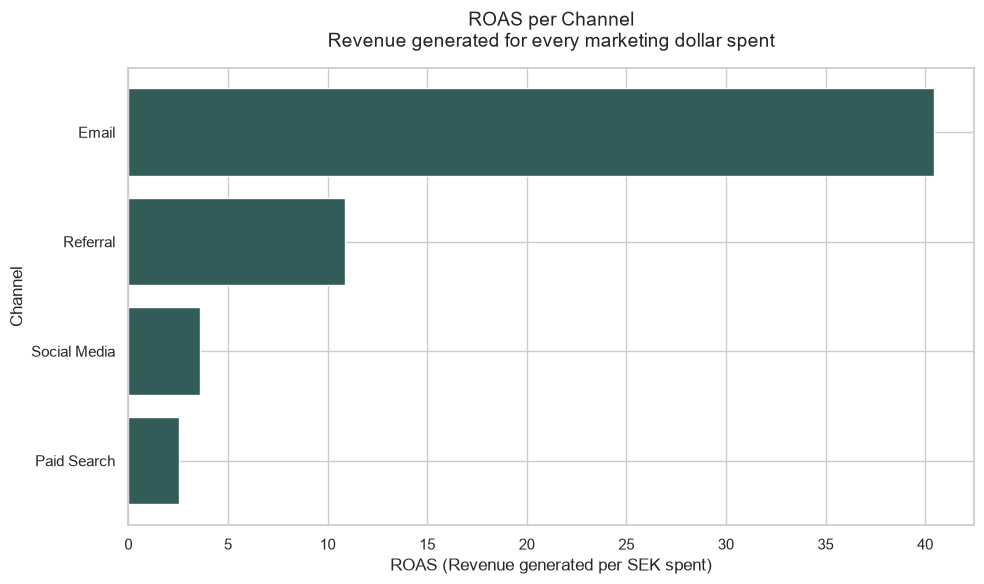

In [11]:
from src.report_tools.visualization import plot_roas_by_channel

fig = plot_roas_by_channel(channel_kpis)

fig.show()